# Point 1 -- Anomaly Detection: Method A vs Method B

This notebook walks through both approaches we built for point 1 of the project
(*"Anomaly Detection via Density Estimation and High-Dimensional Spaces"*),
using the actual modules in `gio/method_a_pca_density/` and
`gio/method_b_autoencoder_hi/`. It re-runs the real pipelines end-to-end so
the numbers and plots below are reproducible, not just described.

**The shared idea behind both methods**: learn what a "healthy" (CN,
Cognitively Normal) brain looks like from CN patients only, then measure how
far every patient (CN, MCI, or AD) deviates from that learned healthy
region. Neither method is ever trained to distinguish MCI from AD; the
diagnosis label is only used afterwards, to check whether the anomaly score
actually lines up with real clinical outcomes.

**Where they differ** is what a single "data point" represents, and what the
output is meant to be used for:

| | Method A (PCA + Hotelling's T²/Q) | Method B (Autoencoder + Health Index) |
|---|---|---|
| Unit of data | one snapshot per patient (baseline visit) | every visit per patient (a sequence over time) |
| Model | PCA -- closed-form, linear, no training loop | small neural network (autoencoder), trained with gradient descent |
| Output | one anomaly score per patient | a trajectory HI(t) per patient + a latent embedding per visit |
| Role in the framework | self-contained -- nothing downstream needs it | pipeline-oriented -- HI(t) is meant to feed point 2 (RUL), the latent embedding is meant to feed point 3 (decision support) |

Both are evaluated the same way: does the anomaly score separate CN from
MCI/AD better than chance (ROC-AUC), and does it look clinically sensible
(CN < MCI < AD)?

## Setup

Both methods live in their own folder with a shared structure: a
`load_*.py` module that builds a clean feature table from the raw ADNI CSVs,
and a `method_*.py` script that fits the model and evaluates it. We import
those modules directly here rather than re-writing the logic, so this
notebook always reflects exactly what the actual pipeline does.

In [1]:
import sys, os

REPO_ROOT = os.path.abspath("../..")  # notebooks/anomaly_detection/ -> repo root
sys.path.insert(0, os.path.join(REPO_ROOT, "notebooks", "anomaly_detection", "method_a_pca_density"))
sys.path.insert(0, os.path.join(REPO_ROOT, "notebooks", "anomaly_detection", "method_b_autoencoder_hi"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 110


---
## Part 1 -- Method A: PCA + Hotelling's T² / Q (SPE)

### 1.1 Building the feature table

`load_features.build_feature_table()` merges DXSUM (diagnosis), PTDEMOG
(demographics) and UCSFFSX7 (structural MRI) into one row per patient. Each
patient's MRI visit is matched to the visit *closest in time* to their
diagnosis date (within `MATCH_WINDOW_DAYS`, 180 days) -- this fixes an
earlier version of the pipeline where each table's independently-earliest
row was used, which let diagnosis and MRI be years apart for ~35% of
patients (see `MRI_EXAMDATE_GAP_DAYS` below).

MRI field codes (e.g. hippocampus volume, entorhinal thickness) were
verified directly against `DATADIC_12Dec2025.csv` -- several codes listed in
`datasets_documentation.md` turned out to be stale and were corrected before
use (documented in `load_features.py`).

In [2]:
from load_features import build_feature_table

df_a, feature_cols_a = build_feature_table(feature_tier="core")

print(f"Patients: {len(df_a)}  |  Features per patient: {len(feature_cols_a)}")
print(df_a["DIAGNOSIS_LABEL"].value_counts())
print()
print("MRI-to-diagnosis date gap (days), summary:")
print(df_a["MRI_EXAMDATE_GAP_DAYS"].describe())


Patients: 464  |  Features per patient: 22
DIAGNOSIS_LABEL
CN     269
MCI    161
AD      34
Name: count, dtype: int64

MRI-to-diagnosis date gap (days), summary:
count    464.000000
mean      18.754310
std       20.636837
min        0.000000
25%        7.000000
50%       13.000000
75%       24.000000
max      160.000000
Name: MRI_EXAMDATE_GAP_DAYS, dtype: float64


### 1.2 Fitting the healthy baseline

PCA is fit **only on CN patients**. We keep enough principal components to
explain 90% of the variance in the CN population -- these components define
the "normal operating region" of brain structure. Two statistics then
measure deviation from that region for every patient:

- **T² (Hotelling's)**: Mahalanobis distance *within* the retained PCA
  subspace -- "an unusual combination of otherwise-normal variation."
- **Q (SPE, squared prediction error)**: reconstruction residual *outside*
  the subspace -- "a pattern the healthy population never showed."

Both are combined into one score, each normalized by its 99% control limit
(UCL) fit on the CN population, so T² and Q contribute on a comparable
scale.

In [3]:
from method_a import fit_pca_baseline, compute_t2_q, control_limits

X_a = df_a[feature_cols_a].values
cn_mask_a = (df_a["DIAGNOSIS_LABEL"] == "CN").values

scaler_a, pca_a, pca_full_a, cum_var_a = fit_pca_baseline(X_a[cn_mask_a])
print(f"Retained {pca_a.n_components_} principal components "
      f"(explains {cum_var_a[pca_a.n_components_-1]:.1%} of CN variance) "
      f"out of {X_a.shape[1]} original features.")

T2, Q = compute_t2_q(X_a, scaler_a, pca_a)
t2_ucl, q_ucl = control_limits(T2[cn_mask_a], Q[cn_mask_a], pca_a.n_components_, cn_mask_a.sum())
df_a["ANOMALY_SCORE"] = T2 / t2_ucl + Q / q_ucl


Retained 14 principal components (explains 91.9% of CN variance) out of 22 original features.


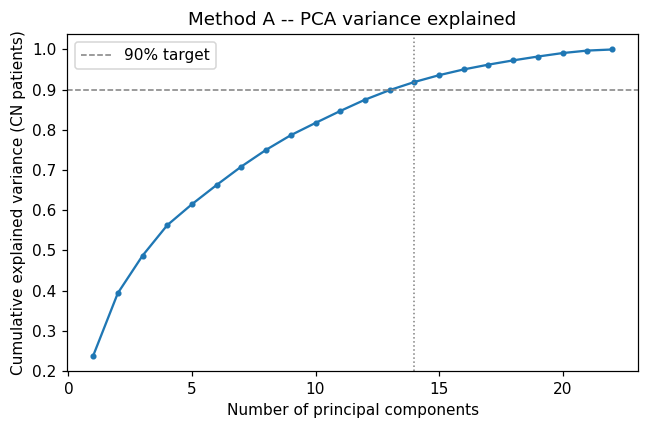

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(cum_var_a) + 1), cum_var_a, marker="o", ms=3)
plt.axhline(0.90, color="gray", ls="--", lw=1, label="90% target")
plt.axvline(pca_a.n_components_, color="gray", ls=":", lw=1)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance (CN patients)")
plt.title("Method A -- PCA variance explained")
plt.legend()
plt.tight_layout()
plt.show()


### 1.3 Does the anomaly score separate CN from MCI/AD?

If Method A is working, the anomaly score should be low for CN patients and
rise for MCI and higher still for AD -- both in the boxplot below and in
ROC-AUC against the real `DIAGNOSIS_LABEL`.

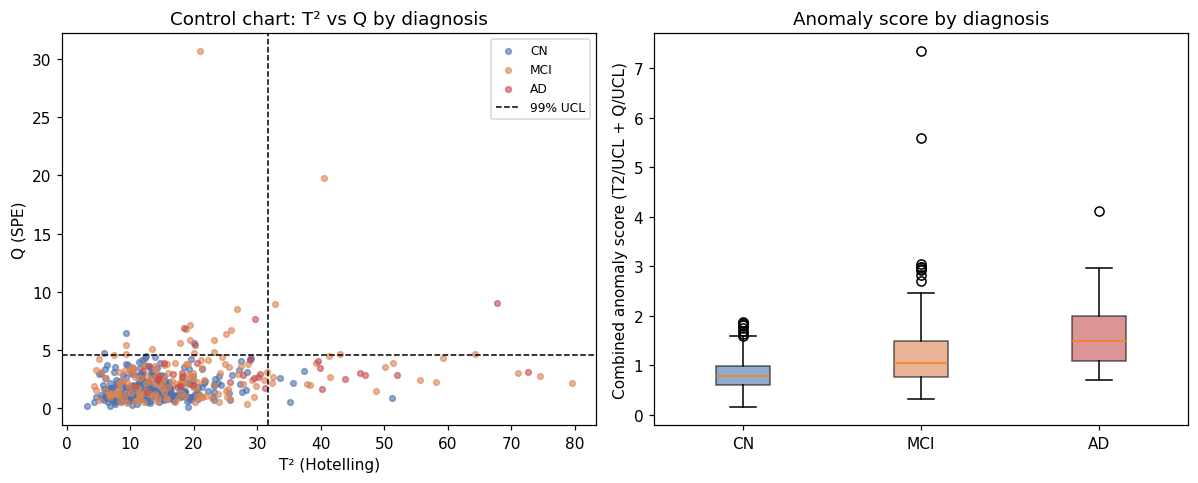

ROC-AUC (Method A anomaly score vs diagnosis):
  CN vs MCI: 0.696
  CN vs AD: 0.890
  CN vs MCI+AD: 0.730


In [5]:
from sklearn.metrics import roc_auc_score

colors = {"CN": "#4C72B0", "MCI": "#DD8452", "AD": "#C44E52"}
order = ["CN", "MCI", "AD"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(T2[cn_mask_a], Q[cn_mask_a], s=14, alpha=0.6, color=colors["CN"], label="CN")
for g in ["MCI", "AD"]:
    m = (df_a["DIAGNOSIS_LABEL"] == g).values
    axes[0].scatter(T2[m], Q[m], s=14, alpha=0.6, color=colors[g], label=g)
axes[0].axvline(t2_ucl, color="k", ls="--", lw=1, label="99% UCL")
axes[0].axhline(q_ucl, color="k", ls="--", lw=1)
axes[0].set_xlabel("T² (Hotelling)")
axes[0].set_ylabel("Q (SPE)")
axes[0].set_title("Control chart: T² vs Q by diagnosis")
axes[0].legend(fontsize=8)

data = [df_a.loc[df_a["DIAGNOSIS_LABEL"] == g, "ANOMALY_SCORE"] for g in order]
bp = axes[1].boxplot(data, tick_labels=order, patch_artist=True)
for patch, g in zip(bp["boxes"], order):
    patch.set_facecolor(colors[g]); patch.set_alpha(0.6)
axes[1].set_ylabel("Combined anomaly score (T2/UCL + Q/UCL)")
axes[1].set_title("Anomaly score by diagnosis")

plt.tight_layout()
plt.show()

print("ROC-AUC (Method A anomaly score vs diagnosis):")
for group in ["MCI", "AD"]:
    mask = cn_mask_a | (df_a["DIAGNOSIS_LABEL"] == group).values
    y = (df_a.loc[mask, "DIAGNOSIS_LABEL"] == group).astype(int)
    print(f"  CN vs {group}: {roc_auc_score(y, df_a.loc[mask, 'ANOMALY_SCORE']):.3f}")
mask_any = cn_mask_a | df_a["DIAGNOSIS_LABEL"].isin(["MCI", "AD"]).values
y_any = (df_a.loc[mask_any, "DIAGNOSIS_LABEL"] != "CN").astype(int)
print(f"  CN vs MCI+AD: {roc_auc_score(y_any, df_a.loc[mask_any, 'ANOMALY_SCORE']):.3f}")


**Reading the result**: AD separates cleanly from CN (AUC ~0.89), MCI is
weaker (AUC ~0.70) -- expected, since MCI is a heterogeneous group where only
some patients are on the way to AD. This matches what published ADNI
structural-MRI studies typically report, which is reassuring: the pipeline
isn't producing numbers out of nowhere.

**What Method A does *not* give you**: a single anomaly score per patient,
computed once. There's no natural way for another model to build further on
top of "0.85" for one patient at one point in time -- this is why we also
built Method B.

---
## Part 2 -- Method B: Autoencoder + Health Index (HI) trajectory

### 2.1 Building the longitudinal table

Unlike Method A, `load_longitudinal.build_longitudinal_table()` keeps
**every** qualifying MRI visit per patient, not just one baseline snapshot --
a patient with 6 scans over 5 years contributes 6 rows. Each visit is
tagged with the diagnosis nearest to it in time.

Note: this loader does **not** filter MRI rows to `STATUS=='complete'` like
Method A does. That QC filter is fine for a single cross-sectional snapshot,
but only 1,065/12,151 UCSFFSX7 rows have that status -- far too few to build
patient *trajectories* with multiple visits each. Checking directly, 11,814
rows already have every needed feature populated regardless of `STATUS`, so
"features present" is used as the QC proxy instead here (documented as a
deliberate, limitation-flagged deviation in the code).

In [6]:
from load_longitudinal import build_longitudinal_table

df_b, feature_cols_b = build_longitudinal_table()
df_b = df_b.dropna(subset=["DIAGNOSIS_LABEL"]).reset_index(drop=True)

baseline_date = df_b.groupby("RID")["EXAMDATE"].transform("min")
df_b["YEARS_FROM_BASELINE"] = (df_b["EXAMDATE"] - baseline_date).dt.days / 365.25

print(f"Visits: {len(df_b)}  |  Patients: {df_b['RID'].nunique()}")
print(df_b.groupby('RID').size().describe())
print()
print("Per-visit diagnosis counts:")
print(df_b["DIAGNOSIS_LABEL"].value_counts())


Visits: 9922  |  Patients: 2093
count    2093.000000
mean        4.740564
std         2.361268
min         1.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
dtype: float64

Per-visit diagnosis counts:
DIAGNOSIS_LABEL
MCI    4457
CN     3471
AD     1994
Name: count, dtype: int64


### 2.2 Training the autoencoder

An autoencoder is a small neural network trained to reconstruct its own
input after squeezing it through a narrow "bottleneck" layer. If it learns
the bottleneck well on **healthy** data, a poor reconstruction on new data
signals that the input doesn't look like anything the network learned as
normal -- that reconstruction error is the anomaly score (the **Health
Index**, HI).

Architecture: 22 input features -> 16 -> **6 (bottleneck)** -> 16 -> 22
output features. Trained only on visits diagnosed CN *at that specific
visit* (not just patients who were CN at baseline). Implemented with
scikit-learn's `MLPRegressor` (trained to predict its own input) rather than
PyTorch, since torch wasn't installable in this environment -- functionally
the same idea, just fit via sklearn's solver instead of a manual training
loop.

In [7]:
from method_b import fit_autoencoder, encode, reconstruction_error, LATENT_DIM

X_b = df_b[feature_cols_b].values
cn_mask_b = (df_b["DIAGNOSIS_LABEL"] == "CN").values
print(f"Training on {cn_mask_b.sum()} CN visits "
      f"({df_b.loc[cn_mask_b, 'RID'].nunique()} unique CN patients).")

scaler_b, ae = fit_autoencoder(X_b[cn_mask_b])
Xs_all = scaler_b.transform(X_b)
df_b["HI"] = reconstruction_error(ae, Xs_all)

latent = encode(ae, Xs_all)
for i in range(LATENT_DIM):
    df_b[f"latent_{i}"] = latent[:, i]

print(f"\nAutoencoder: 16-{LATENT_DIM}-16 MLP, {ae.n_iter_} training iterations, "
      f"final training loss={ae.loss_:.4f}")


Training on 3471 CN visits (823 unique CN patients).

Autoencoder: 16-6-16 MLP, 648 training iterations, final training loss=0.1516


### 2.3 HI trajectories over time

This is the output Method A can't produce: a curve per patient showing how
far their brain drifts from "healthy" as they age through the study --
directly analogous to a degradation curve in industrial condition
monitoring (e.g. a bearing's vibration signal worsening before failure).

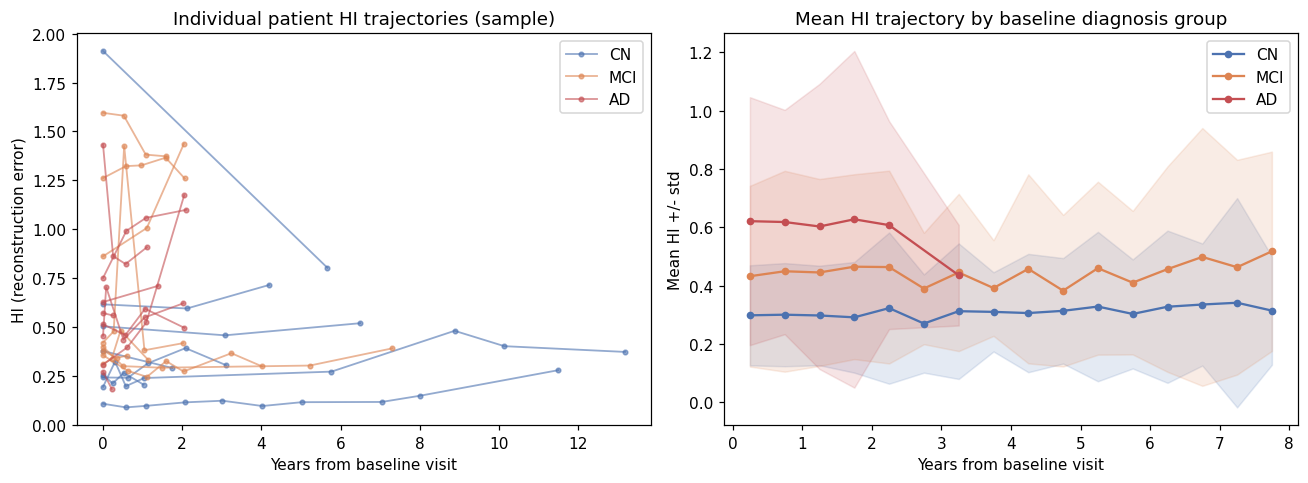

In [8]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for group, color in colors.items():
    rids = df_b.loc[df_b["BASELINE_DIAGNOSIS"] == group, "RID"].unique()
    sample = rng.choice(rids, size=min(8, len(rids)), replace=False)
    for i, rid in enumerate(sample):
        g = df_b[df_b["RID"] == rid].sort_values("YEARS_FROM_BASELINE")
        axes[0].plot(g["YEARS_FROM_BASELINE"], g["HI"], color=color, alpha=0.6,
                      lw=1.2, marker="o", ms=3, label=group if i == 0 else None)
axes[0].set_xlabel("Years from baseline visit")
axes[0].set_ylabel("HI (reconstruction error)")
axes[0].set_title("Individual patient HI trajectories (sample)")
axes[0].legend()

bins = np.arange(0, 8.5, 0.5)
for group, color in colors.items():
    g = df_b[df_b["BASELINE_DIAGNOSIS"] == group].copy()
    g["bin"] = pd.cut(g["YEARS_FROM_BASELINE"], bins)
    stats = g.groupby("bin", observed=True)["HI"].agg(["mean", "std", "count"])
    stats = stats[stats["count"] >= 5]
    x = [iv.mid for iv in stats.index]
    axes[1].plot(x, stats["mean"], color=color, label=group, marker="o", ms=4)
    axes[1].fill_between(x, stats["mean"] - stats["std"], stats["mean"] + stats["std"],
                          color=color, alpha=0.15)
axes[1].set_xlabel("Years from baseline visit")
axes[1].set_ylabel("Mean HI +/- std")
axes[1].set_title("Mean HI trajectory by baseline diagnosis group")
axes[1].legend()

plt.tight_layout()
plt.show()


### 2.4 Does HI *rise faster* for patients heading toward disease?

This is the number that would matter most for point 2 (RUL): the **slope**
of each patient's HI over time. A patient whose HI is climbing quickly is,
intuitively, closer to clinical conversion than one whose HI is flat.

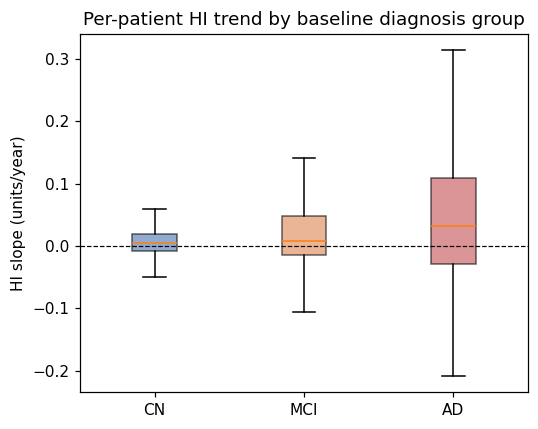

Median / mean HI slope by baseline group:
  CN: median=0.0039, mean=0.0054, n=734
  MCI: median=0.0082, mean=0.0230, n=1000
  AD: median=0.0320, mean=0.0732, n=345


In [9]:
def slope(g):
    if len(g) < 2 or g["YEARS_FROM_BASELINE"].max() == 0:
        return np.nan
    return np.polyfit(g["YEARS_FROM_BASELINE"], g["HI"], 1)[0]

slopes = df_b.groupby("RID").apply(slope, include_groups=False).rename("HI_SLOPE")
slopes_df = df_b.drop_duplicates("RID")[["RID", "BASELINE_DIAGNOSIS"]].merge(slopes, on="RID").dropna()

plt.figure(figsize=(5, 4))
data = [slopes_df.loc[slopes_df["BASELINE_DIAGNOSIS"] == g, "HI_SLOPE"] for g in order]
bp = plt.boxplot(data, tick_labels=order, patch_artist=True, showfliers=False)
for patch, g in zip(bp["boxes"], order):
    patch.set_facecolor(colors[g]); patch.set_alpha(0.6)
plt.axhline(0, color="k", lw=0.8, ls="--")
plt.ylabel("HI slope (units/year)")
plt.title("Per-patient HI trend by baseline diagnosis group")
plt.tight_layout()
plt.show()

print("Median / mean HI slope by baseline group:")
for g in order:
    s = slopes_df.loc[slopes_df["BASELINE_DIAGNOSIS"] == g, "HI_SLOPE"]
    print(f"  {g}: median={s.median():.4f}, mean={s.mean():.4f}, n={len(s)}")


**Reading the result**: median HI slope rises monotonically CN < MCI < AD,
which is exactly the "closer to failure, faster degrading" signal an RUL
model would need to learn to read quantitatively. This is the concrete
handoff point to point 2 of the project.

### 2.5 What Method B hands to the rest of the pipeline

Two things get saved (see `hi_trajectories.csv` in
`method_b_autoencoder_hi/`), and each is meant for a specific next stage:

- **`HI` + `YEARS_FROM_BASELINE`** per visit -> input to point 2 (RUL):
  a degradation trajectory per patient, the same shape of signal an RUL
  model in a PHM (prognostics & health management) pipeline expects.
- **`latent_0`...`latent_5`** per visit -> input to point 3 (decision
  support): a compact, pre-learned patient representation, so that stage
  doesn't need to re-derive features from raw MRI columns.

In [10]:
df_b[["RID", "VISCODE2", "EXAMDATE", "VISIT_INDEX", "YEARS_FROM_BASELINE",
      "DIAGNOSIS_LABEL", "BASELINE_DIAGNOSIS", "HI"] +
     [f"latent_{i}" for i in range(LATENT_DIM)]].head(10)


,RID,VISCODE2,EXAMDATE,VISIT_INDEX,YEARS_FROM_BASELINE,DIAGNOSIS_LABEL,BASELINE_DIAGNOSIS,HI,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5
0,3,sc,2005-09-01,0,0.000000,AD,AD,0.185417,0.0,9.365063,5.071892,5.382862,10.611561,5.120997
1,3,m06,2006-03-13,1,0.528405,AD,AD,0.339115,0.0,9.408442,5.317073,5.325784,9.533165,5.602996
2,3,m12,2006-09-12,2,1.029432,AD,AD,0.189561,0.0,10.393108,5.095331,5.688851,11.069691,5.113201
3,3,m24,2007-09-12,3,2.028747,AD,AD,0.263651,0.0,10.518817,5.583288,5.422957,11.105434,4.662126
4,4,sc,2005-09-22,0,0.000000,MCI,MCI,0.739559,0.0,4.752288,1.996892,3.056157,4.417654,4.181657
5,4,m06,2006-05-25,1,0.670773,MCI,MCI,0.670048,0.0,5.273402,2.060584,3.478294,4.474759,4.307525
6,4,m12,2006-11-28,2,1.182752,MCI,MCI,0.626172,0.0,4.873641,1.383535,2.752181,3.315981,4.759743
7,4,m18,2007-05-25,3,1.670089,MCI,MCI,0.744176,0.0,4.910701,1.850135,3.146737,3.479714,4.322947
8,4,m36,2008-12-09,4,3.214237,MCI,MCI,0.701604,0.0,5.092228,2.265006,3.433539,3.527422,4.845616
9,5,sc,2005-09-02,0,0.000000,CN,CN,0.542204,0.0,4.231139,1.517982,3.579321,4.080041,5.536217


---
## Summary

| | Method A | Method B |
|---|---|---|
| Cohort | 464 patients, 1 row each | 2,093 patients, ~9,900 visits |
| CN vs AD AUC | ~0.89 | ~0.78 |
| CN vs MCI AUC | ~0.70 | ~0.63 |
| Output shape | one score per patient | trajectory + embedding per visit |
| Feeds into | nothing (self-contained) | point 2 (RUL) and point 3 (decision support) |

Method A currently separates AD better -- likely because its per-patient
snapshot is matched tightly (within 90 days on average) to the diagnosis
date, while Method B's visits include looser matches by construction (it
needs many visits per patient, so it can't apply as strict a per-visit QC
filter). That tradeoff -- precision vs. having a trajectory at all -- is
worth stating explicitly in the report rather than treating one method as
simply "better" than the other: they answer different questions.